✅ Semua file berhasil dimuat.
Lokasi dataset: /Users/azzizabdulghofur/Documents/Telkom University/Kompetisi/Lomba/ML-KOMPETISI-INTELLECTRA-2025-IPB/dataset

ANALISIS: Data Anggota (member_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46401 entries, 0 to 46400
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   MemberID        46401 non-null  object
 1   JoinDate        46401 non-null  object
 2   DateOfBirth     1477 non-null   object
 3   City            46401 non-null  object
 4   NoOfChild       46401 non-null  int64 
 5   EldestKidDOB    46401 non-null  object
 6   YoungestKidDOB  46401 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.5+ MB

Statistik Deskriptif:
                                MemberID    JoinDate DateOfBirth    City  \
count                              46401       46401        1477   46401   
unique                             46401        1622         

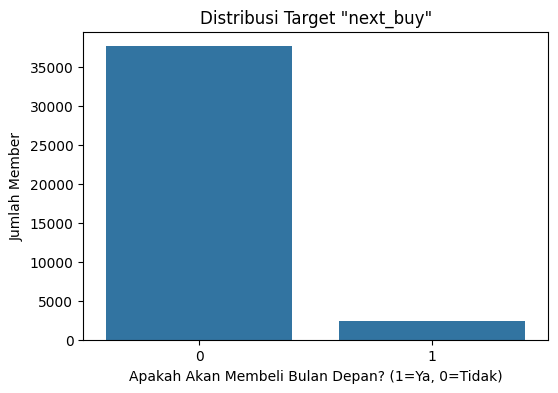


ANALISIS: Data Produk (product_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   productID        27 non-null     int64 
 1   ProductName      27 non-null     object
 2   ProductCategory  27 non-null     object
 3   ProductLevel     27 non-null     object
dtypes: int64(1), object(3)
memory usage: 996.0+ bytes

Jumlah Nilai Hilang:
productID          0
ProductName        0
ProductCategory    0
ProductLevel       0
dtype: int64

Contoh Data:
   productID        ProductName ProductCategory ProductLevel
0          1                A 3               A     Original
1          2                B 4               B     Original
2          3                A G               A      Premium
3          4                B G               B      Premium
4          9  A G FOR HOME KIOS               A      Premium

ANALISIS: Data Prog

In [45]:
# ==============================================================================
# TAHAP 1: IMPORT LIBRARY DAN MEMUAT DATA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur path ke folder dataset dari folder notebooks
# Tanda '..' berarti 'naik satu level direktori'
base_path = '../dataset/'

# Memuat semua dataset yang relevan
try:
    member_df = pd.read_csv(os.path.join(base_path, 'member_data.csv'))
    train_trans_df = pd.read_csv(os.path.join(base_path, 'train_transaction_data.csv'))
    train_label_df = pd.read_csv(os.path.join(base_path, 'train_label_data.csv'))
    product_df = pd.read_csv(os.path.join(base_path, 'product_data.csv'))
    prodgram_df = pd.read_csv(os.path.join(base_path, 'prodgram_data.csv'))
    
    print("✅ Semua file berhasil dimuat.")
    print("Lokasi dataset:", os.path.abspath(base_path))
except FileNotFoundError as e:
    print(f"❌ Gagal memuat file: {e}")
    print("Pastikan file CSV Anda berada di dalam folder 'dataset' dan notebook ini berada di dalam folder 'notebooks'.")

# ==============================================================================
# TAHAP 2: ANALISIS SETIAP TABEL SECARA INDIVIDUAL
# ==============================================================================

print("\n" + "="*50)
print("ANALISIS: Data Anggota (member_data.csv)")
print("="*50)
print("\nInfo Data:")
member_df.info()
print("\nStatistik Deskriptif:")
print(member_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(member_df.isnull().sum())
print("\nContoh Data:")
print(member_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Transaksi Latih (train_transaction_data.csv)")
print("="*50)
print("\nInfo Data:")
train_trans_df.info()
print("\nStatistik Deskriptif:")
print(train_trans_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(train_trans_df.isnull().sum())
print("\nContoh Data:")
print(train_trans_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Label Latih (train_label_data.csv)")
print("="*50)
print("\nInfo Data:")
train_label_df.info()
print("\nJumlah Nilai Hilang:")
print(train_label_df.isnull().sum())
print("\nDistribusi Target (next_buy):")
print(train_label_df['next_buy'].value_counts(normalize=True))
print("\nContoh Data:")
print(train_label_df.head())

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x='next_buy', data=train_label_df)
plt.title('Distribusi Target "next_buy"')
plt.xlabel('Apakah Akan Membeli Bulan Depan? (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Member')
plt.show()


print("\n" + "="*50)
print("ANALISIS: Data Produk (product_data.csv)")
print("="*50)
print("\nInfo Data:")
product_df.info()
print("\nJumlah Nilai Hilang:")
print(product_df.isnull().sum())
print("\nContoh Data:")
print(product_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Program Produk (prodgram_data.csv)")
print("="*50)
print("\nInfo Data:")
prodgram_df.info()
print("\nJumlah Nilai Hilang:")
print(prodgram_df.isnull().sum())
print("\nContoh Data:")
print(prodgram_df.head())


# ==============================================================================
# TAHAP 3: PENGGABUNGAN DATA AWAL (FIRST MERGE)
# ==============================================================================
print("\n" + "="*50)
print("PENGGABUNGAN DATA AWAL")
print("="*50)

# Menggabungkan data transaksi latih dengan labelnya
train_merged_df = pd.merge(train_trans_df, train_label_df, on='MemberID', how='left')

print("Info data setelah digabung dengan label:")
train_merged_df.info()

print("\nJumlah nilai hilang di kolom 'next_buy' setelah merge:")
print(f"{train_merged_df['next_buy'].isnull().sum()} (Seharusnya 0 jika semua MemberID di data transaksi ada di data label)")

print("\nContoh data gabungan:")
print(train_merged_df.head())

In [46]:
# ==============================================================================
# TAHAP 4: PEMBERSIHAN DAN PERSIAPAN DATA (KODE YANG DIPERBAIKI)
# ==============================================================================
print("Memulai proses pembersihan data...")

# Salin dataframe agar data asli tidak berubah
member_clean = member_df.copy()
train_trans_clean = train_trans_df.copy()
prodgram_clean = prodgram_df.copy()

# --- 1. Mengubah Tipe Data Kolom Tanggal ---
print("\n1. Mengubah tipe data kolom tanggal menjadi datetime...")
date_cols_member = ['JoinDate', 'EldestKidDOB', 'YoungestKidDOB']
# Kita tidak memasukkan 'DateOfBirth' karena akan dihapus
for col in date_cols_member:
    member_clean[col] = pd.to_datetime(member_clean[col], errors='coerce')

train_trans_clean['TransactionDatetime'] = pd.to_datetime(train_trans_clean['TransactionDatetime'])

print("Tipe data member_clean setelah diubah:")
print(member_clean.dtypes)
print("\nTipe data train_trans_clean setelah diubah:")
print(train_trans_clean.dtypes)


# --- 2. Menangani Nilai Hilang (Missing Values) ---
print("\n2. Menangani nilai hilang...")

# 2a. DateOfBirth pada member_data kita drop karena >95% hilang
member_clean = member_clean.drop(columns=['DateOfBirth'])
print("- Kolom 'DateOfBirth' telah dihapus.")

# 2b. PricePerUnit pada data transaksi
# Strategi: Isi dengan harga referensi dari prodgram_data
train_trans_clean = pd.merge(
    train_trans_clean,
    prodgram_clean[['prodgramID', 'Price']],
    left_on='FK_PROD_GRAM_ID',
    right_on='prodgramID',
    how='left'
)

# --- INILAH BAGIAN YANG DIPERBAIKI ---
# Mengisi PricePerUnit yang kosong dengan Price dari prodgram
train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(train_trans_clean['Price'])

# Hapus kolom bantu yang sudah tidak diperlukan
train_trans_clean = train_trans_clean.drop(columns=['prodgramID', 'Price'])
print(f"- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: {train_trans_clean['PricePerUnit'].isnull().sum()}")

# Jika masih ada yg kosong, isi dengan median
if train_trans_clean['PricePerUnit'].isnull().sum() > 0:
    median_price = train_trans_clean['PricePerUnit'].median()
    # --- INILAH BAGIAN KEDUA YANG DIPERBAIKI ---
    train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(median_price)
    print(f"- Mengisi sisa nilai hilang 'PricePerUnit' dengan median ({median_price}).")


# --- 3. Menggabungkan Semua Data Menjadi Satu DataFrame Final ---
print("\n3. Menggabungkan semua tabel menjadi satu DataFrame...")

# Gabungkan data transaksi yang sudah bersih dengan data member
df_train_full = pd.merge(train_trans_clean, member_clean, on='MemberID', how='left')

# Gabungkan dengan data produk
product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'})
df_train_full = pd.merge(df_train_full, product_df_renamed, on='FK_PRODUCT_ID', how='left')

# Gabungkan dengan data prodgram (untuk info gramasi & poin)
prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'})
df_train_full = pd.merge(df_train_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left')


print("\n--- DATA BERSIH DAN LENGKAP SIAP UNTUK FEATURE ENGINEERING ---")
print("Info Data Gabungan Final:")
df_train_full.info()

print("\nMemeriksa kembali nilai hilang pada data gabungan:")
# Tampilkan hanya kolom yang masih memiliki nilai hilang
missing_final = df_train_full.isnull().sum()
print(missing_final[missing_final > 0])

Memulai proses pembersihan data...

1. Mengubah tipe data kolom tanggal menjadi datetime...
Tipe data member_clean setelah diubah:
MemberID                  object
JoinDate          datetime64[ns]
DateOfBirth               object
City                      object
NoOfChild                  int64
EldestKidDOB      datetime64[ns]
YoungestKidDOB    datetime64[ns]
dtype: object

Tipe data train_trans_clean setelah diubah:
TransactionID                       object
MemberID                            object
Source                              object
FK_PRODUCT_ID                        int64
FK_PROD_GRAM_ID                      int64
Qty                                  int64
PricePerUnit                       float64
TransactionDatetime    datetime64[ns, UTC]
dtype: object

2. Menangani nilai hilang...
- Kolom 'DateOfBirth' telah dihapus.
- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: 0

3. Menggabungkan semua tabel menjadi satu DataFrame...

--- DATA BERSIH DAN LENGKA

In [47]:
# ==============================================================================
# TAHAP 5: REKAYASA FITUR (DENGAN FITUR BARU & PENYEDERHANAAN)
# ==============================================================================
print("Memulai proses rekayasa fitur...")

# --- 1. Membuat Fitur Dasar per Transaksi ---
df_train_full['TotalPrice'] = df_train_full['Qty'] * df_train_full['PricePerUnit']
df_train_full['DiscountApplied'] = (df_train_full['PricePerUnit'] < df_train_full['Price']).astype(int)

# Tentukan tanggal referensi (snapshot_date)
snapshot_date = df_train_full['TransactionDatetime'].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi untuk recency: {snapshot_date.date()}")


# --- 2. Agregasi Data per MemberID ---
features_df = df_train_full.groupby('MemberID').agg(
    recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days),
    frequency_trans=('TransactionID', 'count'),
    frequency_days=('TransactionDatetime', lambda date: date.dt.date.nunique()),
    monetary_total=('TotalPrice', 'sum'),
    monetary_mean=('TotalPrice', 'mean'),
    monetary_max=('TotalPrice', 'max'),
    product_unique_count=('FK_PRODUCT_ID', 'nunique'),
    category_unique_count=('ProductCategory', 'nunique'),
    total_points=('Point', 'sum'),
    total_discounted_trans=('DiscountApplied', 'sum')
).reset_index()


# --- 3. Membuat Fitur Tambahan ---
features_df['discount_ratio'] = features_df['total_discounted_trans'] / features_df['frequency_trans']
features_df['avg_qty_per_trans'] = df_train_full.groupby('MemberID')['Qty'].sum().reset_index(drop=True) / features_df['frequency_trans']


# --- 4. Menggabungkan dengan Fitur Statis dari Data Member ---
member_static_features = member_clean.drop_duplicates(subset=['MemberID']).copy()
snapshot_date_naive = snapshot_date.tz_localize(None)
member_static_features['tenure_days'] = (snapshot_date_naive - member_static_features['JoinDate']).dt.days
features_df = pd.merge(features_df, member_static_features[['MemberID', 'City', 'NoOfChild', 'tenure_days']], on='MemberID', how='left')


# ======================================================================
# ### MODIFIKASI DIMULAI DI SINI ###
# ======================================================================

print("\nMenambahkan fitur-fitur baru untuk melawan overfitting...")

# --- A. Fitur Agregat Berbasis Waktu (30 hari terakhir) ---
last_month_start = snapshot_date - pd.Timedelta(days=30)
recent_trans_df = df_train_full[df_train_full['TransactionDatetime'] >= last_month_start]

recent_features = recent_trans_df.groupby('MemberID').agg(
    trans_count_30d=('TransactionID', 'count'),
    total_spend_30d=('TotalPrice', 'sum')
).reset_index()

features_df = pd.merge(features_df, recent_features, on='MemberID', how='left')
features_df[['trans_count_30d', 'total_spend_30d']] = features_df[['trans_count_30d', 'total_spend_30d']].fillna(0)
print("- Fitur agregat 30 hari telah ditambahkan.")


# --- B. Menyederhanakan Fitur 'City' ---
city_counts = features_df['City'].value_counts()
rare_cities = city_counts[city_counts < 10].index
features_df['City_simplified'] = features_df['City'].replace(rare_cities, 'LAINNYA')
features_df = features_df.drop(columns='City')
print("- Fitur 'City' telah disederhanakan menjadi 'City_simplified'.")


# ======================================================================
# ### MODIFIKASI SELESAI ###
# ======================================================================


# --- 5. Menggabungkan dengan Label Target (next_buy) ---
final_train_df = pd.merge(features_df, train_label_df, on='MemberID', how='left')


# --- 6. Menangani Nilai Hilang (jika ada) setelah merge ---
if final_train_df['tenure_days'].isnull().any():
    final_train_df['tenure_days'].fillna(final_train_df['tenure_days'].median(), inplace=True)
if final_train_df['discount_ratio'].isnull().any():
    final_train_df['discount_ratio'].fillna(0, inplace=True)


print("\n--- PROSES REKAYASA FITUR SELESAI ---")
print("Dimensi data latih final:", final_train_df.shape)
print("\nContoh Data Latih Final (siap untuk model):")
print(final_train_df.head())

Memulai proses rekayasa fitur...
Tanggal referensi untuk recency: 2021-07-01

Menambahkan fitur-fitur baru untuk melawan overfitting...
- Fitur agregat 30 hari telah ditambahkan.
- Fitur 'City' telah disederhanakan menjadi 'City_simplified'.

--- PROSES REKAYASA FITUR SELESAI ---
Dimensi data latih final: (40020, 19)

Contoh Data Latih Final (siap untuk model):
                           MemberID  recency  frequency_trans  frequency_days  \
0  00010c8a563eb5555709c8ae3120ba2e      161                1               1   
1  000184877b42ade87143636847f305a8      254                1               1   
2  0003a82569e3202cfecc55d987da0f70        3               11              11   
3  00045f29692019c0fa274e5330c5dbaf      116                2               2   
4  0004aec4786c2b071360a0967b39f4f5      132               20              20   

   monetary_total  monetary_mean  monetary_max  product_unique_count  \
0         83000.0   83000.000000       83000.0                     1   
1    

Memulai proses persiapan dan pelatihan model...

Fitur (X) dan Target (y) sudah dipisahkan.

VALIDASI BERBASIS WAKTU: Data latih: 35856 baris, Data validasi: 4164 baris

Melatih model LightGBM dengan parameter regularisasi...
Nilai scale_pos_weight untuk kelas positif: 46.62

Mengevaluasi performa model pada data validasi...

🏆 Balanced Accuracy Score (setelah modifikasi): 0.6867

Laporan Klasifikasi:
                precision    recall  f1-score   support

Tidak Beli (0)       0.75      0.72      0.74      2479
      Beli (1)       0.61      0.65      0.63      1685

      accuracy                           0.69      4164
     macro avg       0.68      0.69      0.68      4164
  weighted avg       0.70      0.69      0.69      4164


Confusion Matrix:


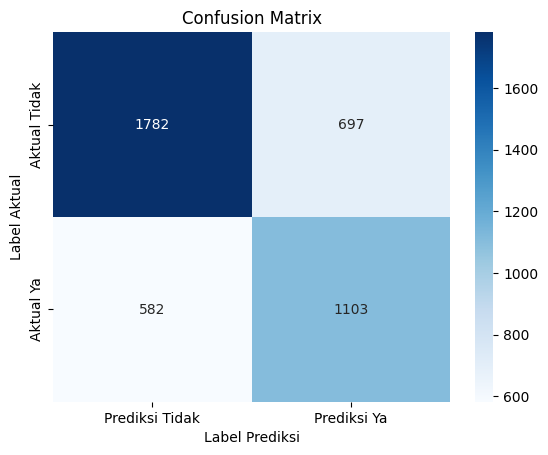

In [48]:
# ==============================================================================
# TAHAP 6: PELATIHAN DAN EVALUASI MODEL (PERBAIKAN FINAL)
# ==============================================================================
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Memulai proses persiapan dan pelatihan model...")

# --- 1. Persiapan Data untuk Model ---
X = final_train_df.drop(columns=['MemberID', 'next_buy'])
y = final_train_df['next_buy']
X['City_simplified'] = X['City_simplified'].astype('category')
print("\nFitur (X) dan Target (y) sudah dipisahkan.")

# --- 2. Validasi Berbasis Waktu ---
last_trans_df = df_train_full.groupby('MemberID')['TransactionDatetime'].max().reset_index()
last_trans_df = last_trans_df.rename(columns={'TransactionDatetime':'LastTransaction'})
split_df = pd.merge(final_train_df, last_trans_df, on='MemberID', how='left')
split_date = split_df['LastTransaction'].max() - pd.DateOffset(months=1)
train_indices = split_df[split_df['LastTransaction'] < split_date].index
val_indices = split_df[split_df['LastTransaction'] >= split_date].index

X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]
X_val = X.iloc[val_indices]
y_val = y.iloc[val_indices]
print(f"\nVALIDASI BERBASIS WAKTU: Data latih: {len(X_train)} baris, Data validasi: {len(X_val)} baris")

# --- 3. Pelatihan Model LightGBM ---
print("\nMelatih model LightGBM dengan parameter regularisasi...")
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Nilai scale_pos_weight untuk kelas positif: {scale_pos_weight:.2f}")

lgbm = lgb.LGBMClassifier(
    objective='binary',
    # Kita hapus 'metric' dari sini untuk menghindari konflik
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    colsample_bytree=0.8,
    n_jobs=-1
)

# ### INILAH BAGIAN YANG DIPERBAIKI SECARA FINAL ###
# Kita secara eksplisit mendefinisikan SEMUA parameter evaluasi di dalam .fit()
lgbm.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         eval_metric='balanced_accuracy',  # <-- Didefinisikan secara eksplisit di sini
         callbacks=[lgb.early_stopping(10, verbose=False)])

# --- 4. Evaluasi Model pada Data Validasi ---
print("\nMengevaluasi performa model pada data validasi...")

y_pred = lgbm.predict(X_val)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
print(f"\n================================================")
print(f"🏆 Balanced Accuracy Score (setelah modifikasi): {balanced_acc:.4f}")
print(f"================================================")

print("\nLaporan Klasifikasi:")
print(classification_report(y_val, y_pred, target_names=['Tidak Beli (0)', 'Beli (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prediksi Tidak', 'Prediksi Ya'], yticklabels=['Aktual Tidak', 'Aktual Ya'])
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.title('Confusion Matrix')
plt.show()

In [49]:
# ==============================================================================
# TAHAP 7: OPTIMASI HIPERPARAMETER DENGAN OPTUNA (PERBAIKAN FINAL)
# ==============================================================================
try:
    import optuna
except ImportError:
    print("Menginstal optuna...")
    !pip install optuna
    import optuna

# Fungsi 'objective' yang sudah diperbaiki
def objective(trial):
    # 1. Tentukan rentang parameter HANYA UNTUK PEMBUATAN MODEL
    params = {
        'objective': 'binary',
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight, # Gunakan dari tahap sebelumnya
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'num_leaves': trial.suggest_int('num_leaves', 15, 40),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'verbose': -1 # Untuk menekan output berlebih dari LightGBM
    }
    
    # 2. Inisialisasi model
    model = lgb.LGBMClassifier(**params)
    
    # 3. Latih model dengan SEMUA parameter evaluasi didefinisikan secara eksplisit di sini
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='balanced_accuracy', # <-- Didefinisikan secara eksplisit di sini
              callbacks=[lgb.early_stopping(15, verbose=False)])
    
    # 4. Evaluasi dan kembalikan skor
    preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, preds)
    
    return score

# Buat dan jalankan studi Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Tampilkan hasil terbaik
print("\n--- OPTIMASI SELESAI ---")
print("Skor Balanced Accuracy terbaik di validasi:", study.best_value)
print("Kombinasi parameter terbaik:", study.best_params)

# Simpan parameter terbaik untuk Tahap 8
best_params = study.best_params

[I 2025-07-08 00:13:03,622] A new study created in memory with name: no-name-a827e6d6-043c-4625-b2dc-fa4c9dfb3b18
Best trial: 0. Best value: 0.692753:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-07-08 00:13:03,716] Trial 0 finished with value: 0.6927528928458997 and parameters: {'n_estimators': 987, 'learning_rate': 0.0634845995528358, 'num_leaves': 36, 'max_depth': 6, 'reg_alpha': 0.1575876371257081, 'reg_lambda': 0.7844889077955963, 'colsample_bytree': 0.8690659382658751}. Best is trial 0 with value: 0.6927528928458997.


Best trial: 0. Best value: 0.692753:   4%|▍         | 2/50 [00:00<00:05,  9.38it/s]

[I 2025-07-08 00:13:03,835] Trial 1 finished with value: 0.6725783225982527 and parameters: {'n_estimators': 651, 'learning_rate': 0.03248451530616842, 'num_leaves': 28, 'max_depth': 7, 'reg_alpha': 0.7001193111644828, 'reg_lambda': 0.8485407937549755, 'colsample_bytree': 0.9857087170878865}. Best is trial 0 with value: 0.6927528928458997.


Best trial: 0. Best value: 0.692753:   6%|▌         | 3/50 [00:00<00:05,  9.36it/s]

...

[I 2025-07-08 00:13:07,884] Trial 43 finished with value: 0.6958303757497699 and parameters: {'n_estimators': 517, 'learning_rate': 0.05896981959884637, 'num_leaves': 37, 'max_depth': 8, 'reg_alpha': 0.4383050710841738, 'reg_lambda': 0.16649784551690328, 'colsample_bytree': 0.773913826093335}. Best is trial 26 with value: 0.7007833157574067.
[I 2025-07-08 00:13:08,002] Trial 44 finished with value: 0.674710057060914 and parameters: {'n_estimators': 632, 'learning_rate': 0.04469963193658583, 'num_leaves': 31, 'max_depth': 8, 'reg_alpha': 0.5862046702779038, 'reg_lambda': 0.09251478511628392, 'colsample_bytree': 0.7257086926598196}. Best is trial 26 with value: 0.7007833157574067.


Best trial: 26. Best value: 0.700783:  94%|█████████▍| 47/50 [00:04<00:00,  9.04it/s]

[I 2025-07-08 00:13:08,122] Trial 45 finished with value: 0.6525172277995699 and parameters: {'n_estimators': 417, 'learning_rate': 0.05297359572505969, 'num_leaves': 37, 'max_depth': 8, 'reg_alpha': 0.4915901100362844, 'reg_lambda': 0.2495202474792869, 'colsample_bytree': 0.7086291417818666}. Best is trial 26 with value: 0.7007833157574067.
[I 2025-07-08 00:13:08,226] Trial 46 finished with value: 0.6914378703961945 and parameters: {'n_estimators': 509, 'learning_rate': 0.061060258487076156, 'num_leaves': 32, 'max_depth': 8, 'reg_alpha': 0.6726608193055252, 'reg_lambda': 0.28995742389940926, 'colsample_bytree': 0.7510638372588853}. Best is trial 26 with value: 0.7007833157574067.
[I 2025-07-08 00:13:08,304] Trial 47 finished with value: 0.5 and parameters: {'n_estimators': 374, 'learning_rate': 0.07571156275610993, 'num_leaves': 24, 'max_depth': 7, 'reg_alpha': 0.6058933769586544, 'reg_lambda': 0.3794512419739898, 'colsample_bytree': 0.8669754034319184}. Best is trial 26 with value: 0

Best trial: 26. Best value: 0.700783: 100%|██████████| 50/50 [00:04<00:00, 10.24it/s]

[I 2025-07-08 00:13:08,407] Trial 48 finished with value: 0.4997866948839091 and parameters: {'n_estimators': 536, 'learning_rate': 0.0630798034265334, 'num_leaves': 34, 'max_depth': 8, 'reg_alpha': 0.7465873245564162, 'reg_lambda': 0.10803152264664925, 'colsample_bytree': 0.9856247121711125}. Best is trial 26 with value: 0.7007833157574067.
[I 2025-07-08 00:13:08,504] Trial 49 finished with value: 0.6956459182952828 and parameters: {'n_estimators': 585, 'learning_rate': 0.07688702228347205, 'num_leaves': 38, 'max_depth': 7, 'reg_alpha': 0.04643553852732081, 'reg_lambda': 0.27214569503123026, 'colsample_bytree': 0.7310023244326261}. Best is trial 26 with value: 0.7007833157574067.

--- OPTIMASI SELESAI ---
Skor Balanced Accuracy terbaik di validasi: 0.7007833157574067
Kombinasi parameter terbaik: {'n_estimators': 702, 'learning_rate': 0.07291397634297321, 'num_leaves': 27, 'max_depth': 8, 'reg_alpha': 0.2512434482570318, 'reg_lambda': 0.4164801556494134, 'colsample_bytree': 0.701154091

In [50]:
# ==============================================================================
# TAHAP 8: FINAL MODEL TRAINING & SUBMISSION (MENGGUNAKAN HASIL OPTUNA)
# ==============================================================================
print("--- Memulai Proses Pembuatan Submission ---")

# --- 1. Final Model Training (menggunakan 100% data latih & parameter terbaik) ---
print("\n1. Melatih model final pada seluruh data latih dengan parameter terbaik...")

X_full_train = final_train_df.drop(columns=['MemberID', 'next_buy'])
y_full_train = final_train_df['next_buy']
X_full_train['City_simplified'] = X_full_train['City_simplified'].astype('category')

# Tambahkan parameter wajib yang tidak di-tuning oleh Optuna ke best_params
best_params['objective'] = 'binary'
best_params['scale_pos_weight'] = y_full_train.value_counts()[0] / y_full_train.value_counts()[1]
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# Inisialisasi model final dengan parameter terbaik
final_lgbm = lgb.LGBMClassifier(**best_params)
final_lgbm.fit(X_full_train, y_full_train)
print("Model final berhasil dilatih.")

# --- 2. Memuat dan Memproses Data Tes (dengan pipeline yang sama persis) ---
print("\n2. Memuat dan memproses data tes...")
test_trans_df = pd.read_csv('../dataset/test_transaction_data.csv')
sample_submission_df = pd.read_csv('../submission/sample_submission.csv')

# Menjalankan SEMUA langkah cleaning & feature engineering yang SAMA pada data tes
test_trans_clean = test_trans_df.copy(); test_trans_clean['TransactionDatetime'] = pd.to_datetime(test_trans_clean['TransactionDatetime']); test_trans_clean = pd.merge(test_trans_clean, prodgram_clean[['prodgramID', 'Price']], left_on='FK_PROD_GRAM_ID', right_on='prodgramID', how='left'); test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(test_trans_clean['Price']); test_trans_clean = test_trans_clean.drop(columns=['prodgramID', 'Price']);
if test_trans_clean['PricePerUnit'].isnull().sum() > 0: median_price_train = X_full_train['PricePerUnit'].median(); test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(median_price_train);
df_test_full = pd.merge(test_trans_clean, member_clean, on='MemberID', how='left'); product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'}); df_test_full = pd.merge(df_test_full, product_df_renamed, on='FK_PRODUCT_ID', how='left'); prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'}); df_test_full = pd.merge(df_test_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left');
df_test_full['TotalPrice'] = df_test_full['Qty'] * df_test_full['PricePerUnit']; df_test_full['DiscountApplied'] = (df_test_full['PricePerUnit'] < df_test_full['Price']).astype(int);
test_features_df = df_test_full.groupby('MemberID').agg(recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days), frequency_trans=('TransactionID', 'count'), frequency_days=('TransactionDatetime', lambda date: date.dt.date.nunique()), monetary_total=('TotalPrice', 'sum'), monetary_mean=('TotalPrice', 'mean'), monetary_max=('TotalPrice', 'max'), product_unique_count=('FK_PRODUCT_ID', 'nunique'), category_unique_count=('ProductCategory', 'nunique'), total_points=('Point', 'sum'), total_discounted_trans=('DiscountApplied', 'sum')).reset_index();
test_features_df['discount_ratio'] = test_features_df['total_discounted_trans'] / test_features_df['frequency_trans']; test_features_df['avg_qty_per_trans'] = df_test_full.groupby('MemberID')['Qty'].sum().reset_index(drop=True) / test_features_df['frequency_trans'];
member_static_features_test = member_clean.drop_duplicates(subset=['MemberID']).copy(); snapshot_date_naive = snapshot_date.tz_localize(None); member_static_features_test['tenure_days'] = (snapshot_date_naive - member_static_features_test['JoinDate']).dt.days; test_features_df = pd.merge(test_features_df, member_static_features_test[['MemberID', 'City', 'NoOfChild', 'tenure_days']], on='MemberID', how='left');
recent_features_test = df_test_full[df_test_full['TransactionDatetime'] >= last_month_start].groupby('MemberID').agg(trans_count_30d=('TransactionID', 'count'), total_spend_30d=('TotalPrice', 'sum')).reset_index()
test_features_df = pd.merge(test_features_df, recent_features_test, on='MemberID', how='left')
test_features_df[['trans_count_30d', 'total_spend_30d']] = test_features_df[['trans_count_30d', 'total_spend_30d']].fillna(0)
test_features_df['City_simplified'] = test_features_df['City'].replace(rare_cities, 'LAINNYA')
test_features_df = test_features_df.drop(columns='City')

final_test_df = pd.merge(sample_submission_df[['MemberID']], test_features_df, on='MemberID', how='left')
final_test_df.fillna(0, inplace=True) 
final_test_df['City_simplified'] = final_test_df['City_simplified'].astype('category')
print("Data tes berhasil diproses.")

# --- 3. Membuat Prediksi dan Menyimpan File ---
print("\n3. Membuat prediksi pada data tes...")
X_test_final = final_test_df[X_full_train.columns]
test_predictions = final_lgbm.predict(X_test_final)
submission_df = pd.DataFrame({'MemberID': final_test_df['MemberID'], 'next_buy': test_predictions})
submission_df.to_csv('../submission/submission_optuna.csv', index=False)

print("\n🎉 File 'submission_optuna.csv' telah berhasil dibuat di folder 'submissions'!")
print(submission_df.head())

--- Memulai Proses Pembuatan Submission ---

1. Melatih model final pada seluruh data latih dengan parameter terbaik...
Model final berhasil dilatih.

2. Memuat dan memproses data tes...
Data tes berhasil diproses.

3. Membuat prediksi pada data tes...

🎉 File 'submission_optuna.csv' telah berhasil dibuat di folder 'submissions'!
                           MemberID  next_buy
0  c2a630e3d0dc77dac0f63424a9ae1438         0
1  3ecf7484c08418953e967a20de37051b         0
2  97bbd6c99a862f20657d9b2b1c77b2c8         0
3  3ce072ff9c6f2f4b7c95dbc08324a24d         0
4  ab0b0de2a1c85a40b5d58644aef745c0         0
